In [1]:
%matplotlib inline
import control
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal

sns.set_style("whitegrid")

Ball & Beam: PID Controller Design


Key MATLAB commands used in this tutorial are:

<http://www.mathworks.com/help/toolbox/control/ref/tf.html |tf|> , 

<http://www.mathworks.com/help/toolbox/control/ref/step.html |step|> , 

<http://www.mathworks.com/help/toolbox/control/ref/feedback.html |feedback|>


The open-loop transfer function of the plant for the ball and beam

experiment is given below:


$$
P(s) = \frac{R(s)}{\Theta(s)} =

-\frac{mgd}{L\left(\frac{J}{R^2}+m\right)}\frac{1}{s^2} \qquad [ \frac{m}{rad} ]
 $$


The design criteria for this problem are:


* Settling time less than 3 seconds

* Overshoot less than 5% 


To see the derivation of the equations for this problem refer to the 

< ?example=BallBeam&section=SystemModeling Ball & Beam: System Modeling> page.


Closed-loop representation


The block diagram for this example with a controller and unity feedback

of the ball's position is shown below:


![feedback_ball.png](figures/feedback_ball.png)


First, we will study the response of the system shown above when a

proportional controller is used. Then, derivative and/or integral control 

will be added if necessary. 


Recall, that the transfer function for a PID controller is:


$$C(s) = K_p + \frac{K_i}{s} + K_d s = \frac{K_d s^2 + K_p s + K_i}{s}$$


Proportional control


The closed-loop transfer function for proportional control with a

proportional gain ($K_p$) equal to 100, can be modeled by copying the 

following lines of MATLAB code into a new < ?aux=Extras_Mfile

m-file>. 


In [2]:

m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6
s = control.tf('s')
P_ball = -m*g*d/L/(J/R**2+m)/s**2

Kp = 1
C = control.TransferFunction([1], [1, 0])  # TODO: Convert pid(Kp) to proper PID controller
sys_cl=control.feedback(C*P_ball,1)


Now, we can model the system's response to a step input of 0.25 m. Add

the following line of code to your m-file and run it. You should get the

following output:


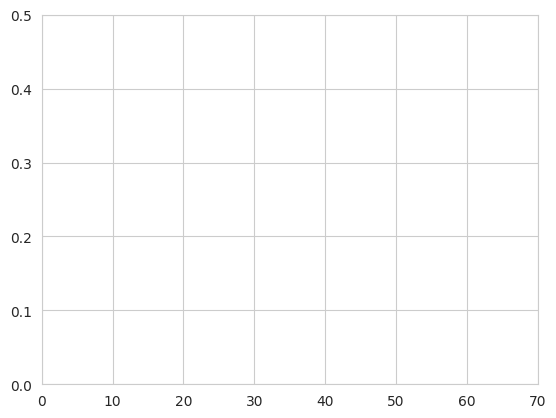

In [3]:

T, yout = control.step_response(0.25*sys_cl)
plt.axis(np.array([0, 70, 0, 0.5]))

plt.show()

As you can see, the system remains marginally stable with the addition of 

a proportional gain. Try changing the value of $K_p$ and note that the system 

remains unstable. 


Proportional-derivative control


Now, we will add a derivative term to the controller. Copy the following

lines of code to an m-file and run it to view the system's response to 

this control method. Your plot should be similar to the following: 


In [4]:
m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6
s = control.tf('s')
P_ball = -m*g*d/L/(J/R**2+m)/s**2

Kp = 10
Kd = 10
C = control.TransferFunction([1], [1, 0])  # TODO: Convert pid(Kp,0,Kd) to proper PID controller

sys_cl=control.feedback(C*P_ball,1)

t=np.arange(0, 5, 0.01)
T, yout = control.step_response(0.25*sys_cl)

plt.show()

Now the system is stable but the overshoot is much too high and the 

settling time needs to go down a bit. From the PID tutorial page in the 

section on characteristics of P, I, and D controllers, we see that by 

increasing $K_d$ we can lower the overshoot and decrease the settling time 

slightly. Therefore, make $K_d$ = 20 in your m-file and run it again. Your 

output should be: 


In [5]:

Kp = 10
Kd = 20
C = control.TransferFunction([1], [1, 0])  # TODO: Convert pid(Kp,0,Kd) to proper PID controller
sys_cl=control.feedback(C*P_ball,1)
T, yout = control.step_response(0.25*sys_cl)

plt.show()

The overshoot criterion is met but the settling time needs to come down a

bit. To decrease the settling time we may try increasing the $K_p$ slightly to 

increase the rise time. The derivative gain ($K_d$) can also be increased to 

take off some of the overshoot that increasing $K_p$ will cause. After playing 

with the gains a bit, the following step response plot can be achieved with 

$K_p$ = 15 and $K_d$ = 40: 


In [6]:

Kp = 15
Kd = 40
C = control.TransferFunction([1], [1, 0])  # TODO: Convert pid(Kp,0,Kd) to proper PID controller
sys_cl=control.feedback(C*P_ball,1)
T, yout = control.step_response(0.25*sys_cl)

plt.show()

As you can see from the above plot all the control objectives have been

met without the use of an integral controller (settling time for this example 

is considered achieved when the response is less than 2% of its final value). 

Remember, that for a control problem there is usually more than one solution 

for the problem.